# KardioSense — Notebook 02 Enhanced: Lead-Agnostic ECG Model
## What's new in this version vs original Notebook 02
This notebook integrates the best techniques from our previous CNN work (Model at the time of presentaion at the NCD Conference in Gulu, August 2025) with the KardioSense architecture:

| Component | Original NB02 | This Version |
|---|---|---|
| Augmentation | Gaussian noise + shift | + **baseline_wander** (from our CNN) |
| Augmentation | Amplitude scale | + **time_stretch** (from our CNN) |
| Batch strategy | WeightedRandomSampler | + **balanced_batch_generator** (from our CNN) |
| Explainability | Attention weights | + **Grad-CAM per-lead** (from our CNN) |
| Visualisation | Basic plots | **Full EDA + confusion matrix + AUC + PR curves** |
| Metrics | AUC only | **AUC, Precision, Recall, F1, Confusion Matrix, MAE** |

**Dataset citation:** PTB-XL (Wagner et al., 2020) + PhysioNet resource citation (Goldberger et al., 2000) — see `REFERENCES.md`.

## 0. Setup — Enable GPU First!
**Runtime → Change runtime type → T4 GPU** before running.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
BASE_DIR = os.environ.get('KARDIOSENSE_BASE_DIR', '/content/drive/MyDrive/KardioSenseAI')
DATA_DIR = f'{BASE_DIR}/datasets'
PTBXL_DIR = f'{DATA_DIR}/ptb-xl'
CKPT_DIR = f'{BASE_DIR}/checkpoints'
LOG_DIR = f'{BASE_DIR}/logs'
for d in [DATA_DIR, PTBXL_DIR, CKPT_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)

CACHE_PATH = f'{DATA_DIR}/ptbxl_preprocessed_500hz.npz'
assert os.path.exists(CACHE_PATH), (
    f'Cache not found. Run Notebook 01 first to build it.'
)
print(f' Cache found: {os.path.getsize(CACHE_PATH)/1e6:.0f} MB')
print(' Drive ready')

Mounted at /content/drive
 Cache found: 933 MB
 Drive ready


In [2]:
!pip install -q wfdb neurokit2
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal as scipy_signal
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report, average_precision_score
)
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import math, time, json, warnings, seaborn as sns
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    print(f'VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print(' No GPU detected — training will be slow. Enable T4 GPU in runtime settings.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 111.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## 1. Load Preprocessed Cache

In [3]:
print('Loading preprocessed cache...')
t0 = time.time()
cache = np.load(CACHE_PATH)
X = cache['X'] # (N, 5000, 12)
Y = cache['Y'] # (N, 5)
ecg_ids = cache['ecg_ids']
print(f' Loaded in {time.time()-t0:.1f}s')
print(f' X : {X.shape} (records × samples × leads)')
print(f' Y : {Y.shape} (records × classes)')

FS = 500
N_SAMPLES = 5000
LABEL_NAMES = ['NORM', 'MI', 'AFIB', 'STTC', 'CD']
ALL_LEADS = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']
SIX_LEAD_INDICES = [0, 1, 2, 5, 7, 9] # I, II, III, aVF, V2, V4
SIX_LEAD_NAMES = [ALL_LEADS[i] for i in SIX_LEAD_INDICES]
print(f'\n6-lead config: {SIX_LEAD_NAMES}')

Loading preprocessed cache...
 Loaded in 34.0s
   X : (4183, 5000, 12)  (records × samples × leads)
   Y : (4183, 5)  (records × classes)

6-lead config: ['I', 'II', 'III', 'aVF', 'V2', 'V4']


## 2. Exploratory Data Analysis
Full dataset statistics before training — understanding the data is as important as the model.

In [4]:
# ── EDA: Dataset overview ─────────────────────────────────────────────────
print('='*55)
print('KARDIOSENSE PTB-XL DATASET — EXPLORATORY DATA ANALYSIS')
print('='*55)
print(f' Total records : {len(X):,}')
print(f' Sampling rate : {FS} Hz')
print(f' Duration : {N_SAMPLES/FS:.0f} seconds per record')
print(f' Signal shape : {X.shape} (records, samples, leads)')

# Label statistics
print(f'\nLabel Distribution:')
print(f' {"Class":8s} {"Count":>6s} {"Rate":>6s} {"Bar"}')
print(' ' + '─'*50)
for i, lbl in enumerate(LABEL_NAMES):
    n = int(Y[:, i].sum())
    pct = n / len(Y) * 100
    bar = '█' * int(pct / 2)
    print(f' {lbl:8s} {n:6,} {pct:5.1f}% {bar}')

# Multi-label statistics
n_multilabel = (Y.sum(axis=1) > 1).sum()
print(f'\n Multi-label records : {n_multilabel:,} ({n_multilabel/len(Y)*100:.1f}%)')

# Signal statistics
print(f'\nSignal Statistics (across all leads, all records):')
flat = X.flatten()
print(f' Mean : {flat.mean():.4f}')
print(f' Std : {flat.std():.4f}')
print(f' P5 : {np.percentile(flat,5):.4f}')
print(f' P95 : {np.percentile(flat,95):.4f}')

# Per-lead statistics
print(f'\nPer-Lead Signal Energy (mean squared amplitude):')
for i, lname in enumerate(ALL_LEADS):
    energy = np.mean(X[:, :, i]**2)
    print(f' {lname:4s}: {energy:.4f}')

KARDIOSENSE PTB-XL DATASET — EXPLORATORY DATA ANALYSIS
  Total records    : 4,183
  Sampling rate    : 500 Hz
  Duration         : 10 seconds per record
  Signal shape     : (4183, 5000, 12)  (records, samples, leads)

Label Distribution:
  Class      Count    Rate  Bar
  ──────────────────────────────────────────────────
  NORM       2,044   48.9%  ████████████████████████
  MI           497   11.9%  █████
  AFIB          21    0.5%  
  STTC       1,042   24.9%  ████████████
  CD         1,086   26.0%  ████████████

  Multi-label records : 474 (11.3%)

Signal Statistics (across all leads, all records):
  Mean  : -0.0000
  Std   : 1.0000
  P5    : -0.9646
  P95   : 1.3280

Per-Lead Signal Energy (mean squared amplitude):
  I   : 1.0000
  II  : 1.0000
  III : 1.0000
  aVR : 1.0000
  aVL : 1.0000
  aVF : 1.0000
  V1  : 1.0000
  V2  : 1.0000
  V3  : 1.0000
  V4  : 1.0000
  V5  : 1.0000
  V6  : 1.0000


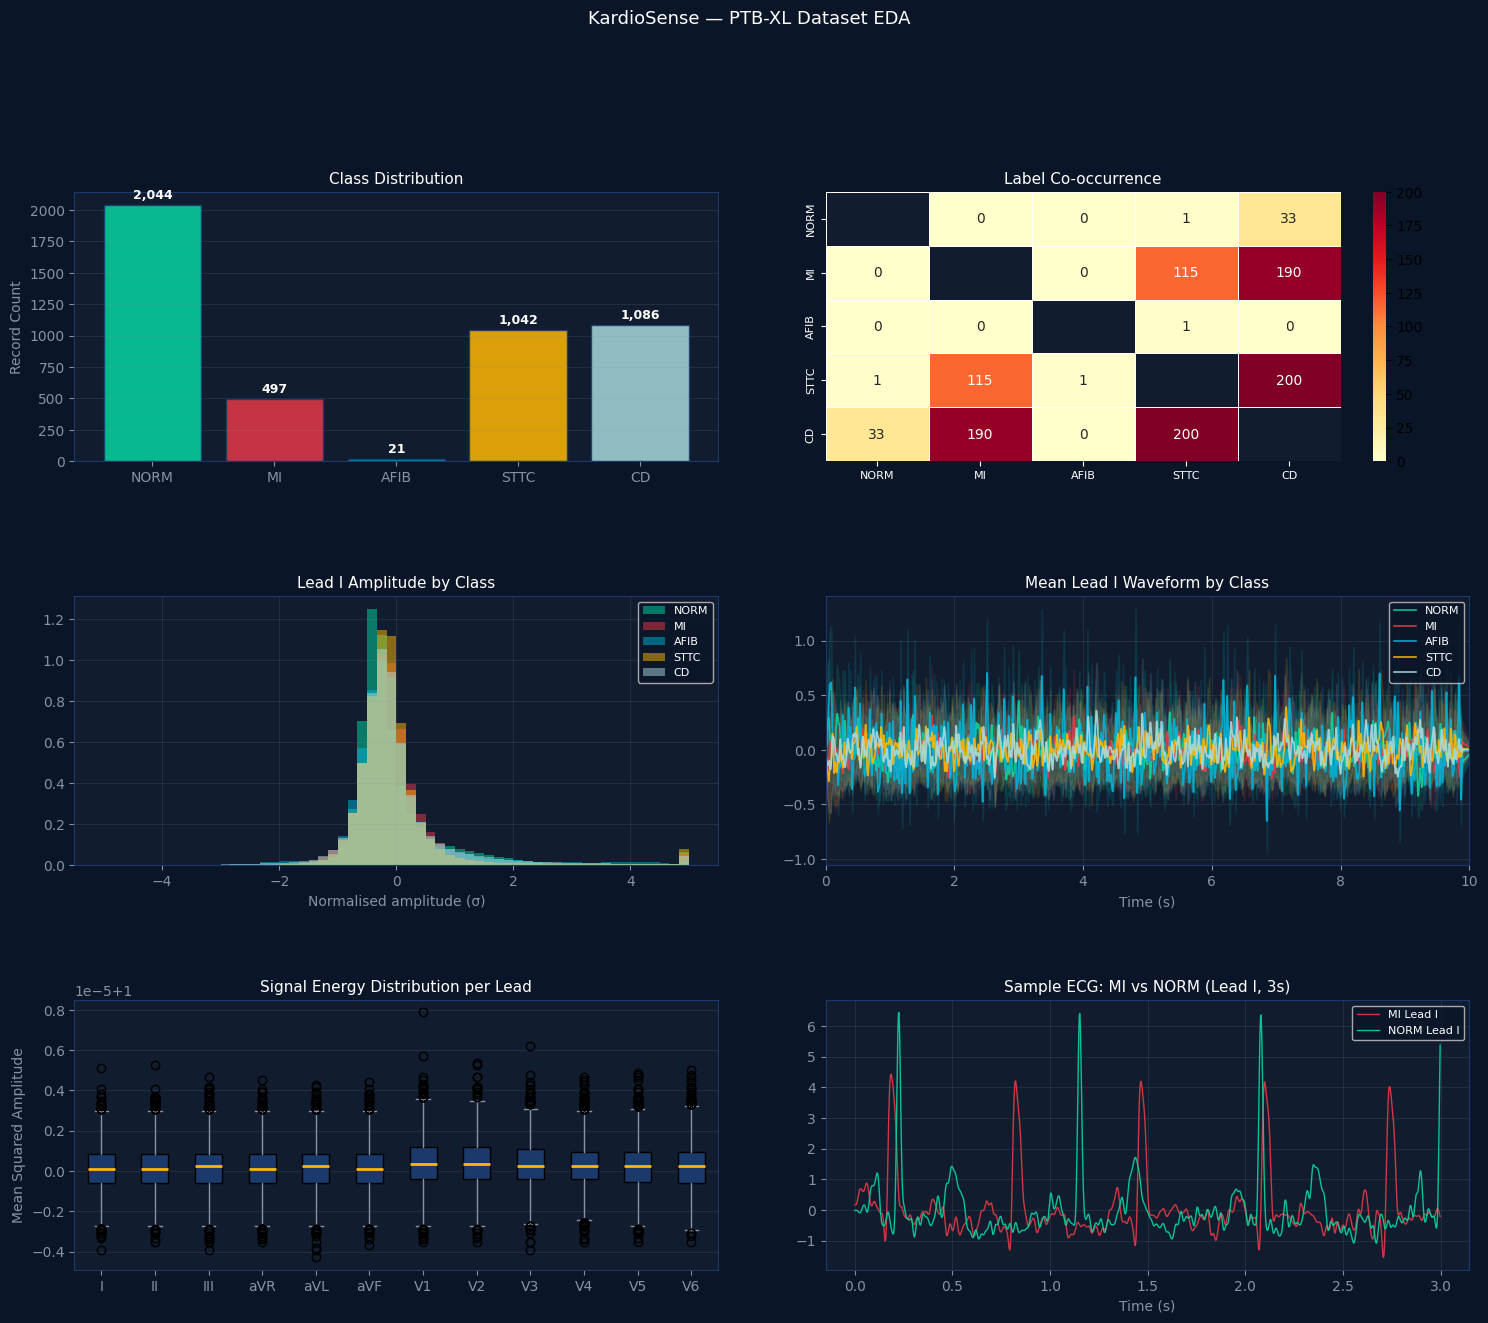

EDA plots saved.


In [5]:
# ── EDA Visualisation ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14), facecolor='#0A1628')
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.5, wspace=0.4)

# ── Panel 1: Class distribution bar chart
ax = fig.add_subplot(gs[0, 0:2])
ax.set_facecolor('#111D2E')
for s in ax.spines.values(): s.set_edgecolor('#1B3A6B')
ax.tick_params(colors='#8892A4')
counts = Y.sum(axis=0)
colors_bar = ['#06D6A0','#E63946','#00B4D8','#FFB703','#A8DADC']
bars = ax.bar(LABEL_NAMES, counts, color=colors_bar, alpha=0.85, edgecolor='#1B3A6B')
for bar, n in zip(bars, counts):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
            f'{int(n):,}', ha='center', color='white', fontsize=9, fontweight='bold')
ax.set_title('Class Distribution', color='white', fontsize=11)
ax.set_ylabel('Record Count', color='#8892A4')
ax.grid(True, alpha=0.15, axis='y', color='#8892A4')

# ── Panel 2: Class co-occurrence heatmap
ax = fig.add_subplot(gs[0, 2:4])
ax.set_facecolor('#111D2E')
cooc = Y.T @ Y # (5, 5) co-occurrence matrix
mask = np.zeros_like(cooc, dtype=bool)
np.fill_diagonal(mask, True)
sns.heatmap(cooc, annot=True, fmt='.0f', xticklabels=LABEL_NAMES,
            yticklabels=LABEL_NAMES, ax=ax, cmap='YlOrRd',
            mask=mask, linewidths=0.5)
ax.set_title('Label Co-occurrence', color='white', fontsize=11)
ax.tick_params(colors='white', labelsize=8)

# ── Panel 3: Signal amplitude distribution per class (Lead I)
ax = fig.add_subplot(gs[1, 0:2])
ax.set_facecolor('#111D2E')
for s in ax.spines.values(): s.set_edgecolor('#1B3A6B')
ax.tick_params(colors='#8892A4')
ax.grid(True, alpha=0.15, color='#8892A4')
for i, (lbl, col) in enumerate(zip(LABEL_NAMES, colors_bar)):
    vals = X[Y[:, i]==1, :, 0].flatten()
    vals = np.clip(vals, -5, 5)
    ax.hist(vals, bins=60, alpha=0.5, color=col, label=lbl, density=True)
ax.set_title('Lead I Amplitude by Class', color='white', fontsize=11)
ax.set_xlabel('Normalised amplitude (σ)', color='#8892A4')
ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=8)

# ── Panel 4: Mean waveform per class (Lead I)
ax = fig.add_subplot(gs[1, 2:4])
ax.set_facecolor('#111D2E')
for s in ax.spines.values(): s.set_edgecolor('#1B3A6B')
ax.tick_params(colors='#8892A4')
ax.grid(True, alpha=0.15, color='#8892A4')
t = np.arange(N_SAMPLES) / FS
for i, (lbl, col) in enumerate(zip(LABEL_NAMES, colors_bar)):
    idx = np.where(Y[:, i]==1)[0][:100]
    if len(idx) == 0: continue
    mean_sig = X[idx, :, 0].mean(axis=0)
    std_sig = X[idx, :, 0].std(axis=0)
    ax.plot(t, mean_sig, color=col, linewidth=1.2, label=lbl, alpha=0.9)
    ax.fill_between(t, mean_sig-std_sig*0.3, mean_sig+std_sig*0.3,
                    color=col, alpha=0.1)
ax.set_title('Mean Lead I Waveform by Class', color='white', fontsize=11)
ax.set_xlabel('Time (s)', color='#8892A4')
ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=8)
ax.set_xlim(0, 10)

# ── Panel 5: Per-lead energy box plot
ax = fig.add_subplot(gs[2, 0:2])
ax.set_facecolor('#111D2E')
for s in ax.spines.values(): s.set_edgecolor('#1B3A6B')
ax.tick_params(colors='#8892A4')
ax.grid(True, alpha=0.15, axis='y', color='#8892A4')
energies = [np.mean(X[:, :, i]**2, axis=1) for i in range(12)]
bp = ax.boxplot(energies, labels=ALL_LEADS, patch_artist=True,
                medianprops=dict(color='#FFB703', linewidth=2))
for patch in bp['boxes']: patch.set_facecolor('#1B3A6B')
for w in bp['whiskers']+bp['caps']+bp['fliers']:
    w.set_color('#8892A4')
ax.set_title('Signal Energy Distribution per Lead', color='white', fontsize=11)
ax.set_ylabel('Mean Squared Amplitude', color='#8892A4')

# ── Panel 6: Sample ECG visualisation
ax = fig.add_subplot(gs[2, 2:4])
ax.set_facecolor('#111D2E')
for s in ax.spines.values(): s.set_edgecolor('#1B3A6B')
ax.tick_params(colors='#8892A4')
ax.grid(True, alpha=0.15, color='#8892A4')
t3 = np.arange(1500) / FS # 3 seconds
mi_idx = np.where(Y[:, 1]==1)[0][0] # first MI record
ax.plot(t3, X[mi_idx, :1500, 0], color='#E63946', linewidth=1, label='MI Lead I', alpha=0.9)
norm_idx = np.where(Y[:, 0]==1)[0][0]
ax.plot(t3, X[norm_idx, :1500, 0], color='#06D6A0', linewidth=1, label='NORM Lead I', alpha=0.9)
ax.set_title('Sample ECG: MI vs NORM (Lead I, 3s)', color='white', fontsize=11)
ax.set_xlabel('Time (s)', color='#8892A4')
ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=8)

plt.suptitle('KardioSense — PTB-XL Dataset EDA', color='white', fontsize=13, y=1.01)
plt.savefig(f'{LOG_DIR}/nb02_eda.png', dpi=120, bbox_inches='tight', facecolor='#0A1628')
plt.show()
print('EDA plots saved.')

## 3. Train / Val / Test Split

In [6]:
df_meta = pd.read_csv(f'{PTBXL_DIR}/ptbxl_database.csv', index_col='ecg_id')
df_filtered = df_meta.loc[ecg_ids]
train_idx = np.where(df_filtered['strat_fold'].isin(range(1, 9)))[0]
val_idx = np.where(df_filtered['strat_fold'] == 9)[0]
test_idx = np.where(df_filtered['strat_fold'] == 10)[0]
X_train, Y_train = X[train_idx], Y[train_idx]
X_val, Y_val = X[val_idx], Y[val_idx]
X_test, Y_test = X[test_idx], Y[test_idx]
print(f'Train={len(X_train):,} Val={len(X_val):,} Test={len(X_test):,}')
print(f'\nLabel rates:')
for lbl, tr, va, te in zip(LABEL_NAMES,
    Y_train.mean(0), Y_val.mean(0), Y_test.mean(0)):
    print(f' {lbl:6s}: train={tr:.3f} val={va:.3f} test={te:.3f}')

Train=3,195  Val=489  Test=499

Label rates:
  NORM  : train=0.501  val=0.436  test=0.459
  MI    : train=0.110  val=0.164  test=0.128
  AFIB  : train=0.004  val=0.014  test=0.004
  STTC  : train=0.243  val=0.270  test=0.269
  CD    : train=0.261  val=0.272  test=0.236


## 4. Enhanced Dataset with Augmentation
**Integrated from our CNN notebook:**
- `baseline_wander` — simulates low-frequency electrode drift (most common real-world artifact)
- `time_stretch` — simulates slight heart rate variability
- `amplitude_scale` — simulates lead placement variability
- `balanced_batch_generator` — ensures each batch has equal positive/negative ratio

In [7]:
from scipy.signal import resample

# ── Augmentation functions (from our Deep_learning_model.ipynb) ──────────
def add_gaussian_noise(ecg: np.ndarray, noise_std: float = 0.02) -> np.ndarray:
    """Add zero-mean Gaussian noise. Simulates ADC quantisation noise."""
    return ecg + noise_std * np.random.randn(*ecg.shape).astype(np.float32)

def time_stretch(ecg: np.ndarray, min_factor: float = 0.95,
                 max_factor: float = 1.05) -> np.ndarray:
    """Stretch or compress time axis. Simulates HR variability."""
    length = ecg.shape[-1]
    factor = np.random.uniform(min_factor, max_factor)
    new_len = max(1, int(length * factor))
    stretched = resample(ecg, new_len, axis=-1).astype(np.float32)
    if new_len > length:
        return stretched[..., :length]
    elif new_len < length:
        pad = length - new_len
        return np.pad(stretched, [(0,0),(0,pad)], mode='edge').astype(np.float32)
    return stretched

def amplitude_scale(ecg: np.ndarray, min_scale: float = 0.85,
                    max_scale: float = 1.15) -> np.ndarray:
    """Scale amplitude. Simulates electrode contact resistance variability."""
    return ecg * np.random.uniform(min_scale, max_scale)

def baseline_wander(ecg: np.ndarray, fs: int = 500,
                    min_freq: float = 0.2, max_freq: float = 0.5,
                    max_amp: float = 0.05) -> np.ndarray:
    """Add sinusoidal baseline drift. Most common real-world ECG artifact.
    Simulates patient breathing and electrode movement.
    Critical for African field deployment where electrode adhesion is variable."""
    n = ecg.shape[-1]
    t = np.arange(n) / fs
    freq = np.random.uniform(min_freq, max_freq)
    amp = np.random.uniform(0.0, max_amp)
    drift = (amp * np.sin(2 * np.pi * freq * t)).astype(np.float32)
    # Apply to all leads (drift[None,:] broadcasts across lead dimension)
    return ecg + drift[np.newaxis, :]

def augment_ecg(ecg: np.ndarray, fs: int = 500) -> np.ndarray:
    """Compose all augmentations. Applied per-sample during training."""
    ecg = add_gaussian_noise(ecg, noise_std=np.random.uniform(0.005, 0.03))
    ecg = time_stretch(ecg, min_factor=0.96, max_factor=1.04)
    ecg = amplitude_scale(ecg, min_scale=0.88, max_scale=1.12)
    if np.random.rand() < 0.5:
        ecg = baseline_wander(ecg, fs=fs)
    return ecg


class LeadAgnosticECGDataset(Dataset):
    """ECG Dataset with lead-agnostic masking + augmentation."""

    MASK_PROBS = {
        'all_leads' : 0.40,
        'lead_I_only' : 0.20,
        'two_leads' : 0.15,
        'three_leads' : 0.15,
        'four_leads' : 0.10,
    }

    def __init__(self, X, Y, lead_indices, apply_masking=True, augment=False):
        self.X, self.Y = X, Y
        self.lead_indices = lead_indices
        self.n_leads = len(lead_indices)
        self.apply_masking = apply_masking
        self.augment = augment

    def __len__(self): return len(self.X)

    def _sample_mask(self):
        strategy = np.random.choice(list(self.MASK_PROBS.keys()),
                                    p=list(self.MASK_PROBS.values()))
        mask = np.zeros(self.n_leads, dtype=np.float32)
        if strategy == 'all_leads': mask[:] = 1.0
        elif strategy == 'lead_I_only': mask[0] = 1.0
        elif strategy == 'two_leads': mask[np.random.choice(self.n_leads,2,replace=False)]=1.0; mask[0]=1.0
        elif strategy == 'three_leads': mask[np.random.choice(self.n_leads,3,replace=False)]=1.0; mask[0]=1.0
        elif strategy == 'four_leads': mask[np.random.choice(self.n_leads,4,replace=False)]=1.0; mask[0]=1.0
        return mask

    def __getitem__(self, idx):
        x = self.X[idx][:, self.lead_indices].T.copy().astype(np.float32) # (n_leads,5000)
        if self.augment:
            x = augment_ecg(x)
        mask = self._sample_mask() if self.apply_masking else np.ones(self.n_leads, np.float32)
        x = x * mask[:, np.newaxis]
        return (torch.tensor(x, dtype=torch.float32),
                torch.tensor(mask, dtype=torch.float32),
                torch.tensor(self.Y[idx], dtype=torch.float32))


# Balanced batch generator (from our CNN notebook)
def balanced_batch_generator(dataset, batch_size=64, pos_fraction=0.5,
                              target_class_idx=1):
    """
    Yields batches with guaranteed pos_fraction positive samples.
    Applies augmentation to positive samples (minority class).
    This is more effective than WeightedRandomSampler for severe imbalance.
    """
    labels = dataset.Y[:, target_class_idx]
    pos_idx = np.where(labels == 1)[0]
    neg_idx = np.where(labels == 0)[0]
    n_pos_batch = int(round(batch_size * pos_fraction))
    n_neg_batch = batch_size - n_pos_batch
    while True:
        np.random.shuffle(pos_idx); np.random.shuffle(neg_idx)
        for start in range(0, len(neg_idx), n_neg_batch):
            neg_batch = neg_idx[start:start+n_neg_batch]
            if len(neg_batch) < n_neg_batch:
                extra = np.random.choice(neg_idx, n_neg_batch-len(neg_batch), replace=True)
                neg_batch = np.concatenate([neg_batch, extra])
            pos_batch = np.random.choice(pos_idx, n_pos_batch, replace=True)
            sigs, masks, lbls = [], [], []
            for i in neg_batch: s,m,l = dataset[i]; sigs.append(s); masks.append(m); lbls.append(l)
            for i in pos_batch: s,m,l = dataset[i]; sigs.append(s); masks.append(m); lbls.append(l)
            perm = torch.randperm(len(sigs))
            yield (torch.stack(sigs)[perm],
                   torch.stack(masks)[perm],
                   torch.stack(lbls)[perm])


BATCH_SIZE = 64
train_ds = LeadAgnosticECGDataset(X_train,Y_train,SIX_LEAD_INDICES,apply_masking=True, augment=True)
val_ds = LeadAgnosticECGDataset(X_val, Y_val, SIX_LEAD_INDICES,apply_masking=False,augment=False)
test_ds = LeadAgnosticECGDataset(X_test, Y_test, SIX_LEAD_INDICES,apply_masking=False,augment=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f' Datasets ready Train={len(train_ds):,} Val={len(val_ds):,} Test={len(test_ds):,}')
print(f' Augmentation: gaussian_noise + time_stretch + amplitude_scale + baseline_wander')

 Datasets ready  Train=3,195 Val=489 Test=499
   Augmentation: gaussian_noise + time_stretch + amplitude_scale + baseline_wander


## 5. Model Architecture: ResNet-1D + BiLSTM + Attention

In [8]:
class ResBlock1D(nn.Module):
    def __init__(self,in_ch,out_ch,kernel_size=7,stride=1,dropout=0.2):
        super().__init__()
        pad = kernel_size//2
        self.conv1 = nn.Conv1d(in_ch,out_ch,kernel_size,stride=stride,padding=pad,bias=False)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch,out_ch,kernel_size,stride=1,padding=pad,bias=False)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.drop = nn.Dropout(dropout)
        self.skip = nn.Sequential(
            nn.Conv1d(in_ch,out_ch,1,stride=stride,bias=False), nn.BatchNorm1d(out_ch)
        ) if (in_ch!=out_ch or stride!=1) else nn.Identity()
    def forward(self,x):
        r=self.skip(x); o=F.relu(self.bn1(self.conv1(x))); o=self.drop(o)
        return F.relu(self.bn2(self.conv2(o))+r)

class AttentionPool(nn.Module):
    def __init__(self,d): super().__init__(); self.a=nn.Linear(d,1)
    def forward(self,x):
        w=torch.softmax(self.a(x),dim=1)
        return (x*w).sum(dim=1), w.squeeze(-1)

class KardioSenseECGModel(nn.Module):
    def __init__(self,n_leads=6,n_classes=5,dropout=0.3):
        super().__init__()
        self.stem=nn.Sequential(
            nn.Conv1d(n_leads,32,15,stride=2,padding=7,bias=False),
            nn.BatchNorm1d(32),nn.ReLU(),nn.MaxPool1d(3,stride=2,padding=1))
        self.layer1=ResBlock1D(32, 64, stride=2,dropout=dropout)
        self.layer2=ResBlock1D(64, 128,stride=2,dropout=dropout)
        self.layer3=ResBlock1D(128,256,stride=2,dropout=dropout)
        self.layer4=ResBlock1D(256,256,stride=2,dropout=dropout)
        self.bilstm=nn.LSTM(256,128,num_layers=2,batch_first=True,
                            bidirectional=True,dropout=dropout)
        self.self_attn=nn.MultiheadAttention(256,4,dropout=dropout,batch_first=True)
        self.attn_norm=nn.LayerNorm(256)
        self.attn_pool=AttentionPool(256)
        self.mask_proj=nn.Sequential(nn.Linear(n_leads,32),nn.ReLU())
        self.classifier=nn.Sequential(
            nn.Linear(288,128),nn.ReLU(),nn.Dropout(dropout),nn.Linear(128,n_classes))

    def forward(self,sig,mask):
        x=self.layer4(self.layer3(self.layer2(self.layer1(self.stem(sig)))))
        x=x.permute(0,2,1); x,_=self.bilstm(x)
        ao,_=self.self_attn(x,x,x); x=self.attn_norm(x+ao)
        e,aw=self.attn_pool(x)
        return self.classifier(torch.cat([e,self.mask_proj(mask)],dim=-1)), aw

    def get_ecg_embedding(self,sig,mask):
        x=self.layer4(self.layer3(self.layer2(self.layer1(self.stem(sig)))))
        x=x.permute(0,2,1); x,_=self.bilstm(x)
        ao,_=self.self_attn(x,x,x); x=self.attn_norm(x+ao)
        e,_=self.attn_pool(x); return e

model = KardioSenseECGModel(n_leads=len(SIX_LEAD_INDICES),
                             n_classes=len(LABEL_NAMES),dropout=0.3).to(DEVICE)
total_p = sum(p.numel() for p in model.parameters())
print(f' Model: ResNet1D + BiLSTM(×2) + MultiHeadAttn + AttentionPool')
print(f' Input : (batch, 6 leads [{" ".join(SIX_LEAD_NAMES)}], 5000 samples)')
print(f' Output : (batch, 5) classes + attention weights')
print(f' Params : {total_p:,}')
with torch.no_grad():
    dummy_s=torch.randn(2,6,5000).to(DEVICE); dummy_m=torch.ones(2,6).to(DEVICE)
    o,aw=model(dummy_s,dummy_m)
    print(f' Test pass: logits={o.shape} attn_weights={aw.shape} ')

 Model: ResNet1D + BiLSTM(×2) + MultiHeadAttn + AttentionPool
   Input  : (batch, 6 leads [I II III aVF V2 V4], 5000 samples)
   Output : (batch, 5) classes + attention weights
   Params : 3,028,710
   Test pass: logits=torch.Size([2, 5])  attn_weights=torch.Size([2, 79])  ✓


## 6. Training

In [9]:
n_pos = Y_train.sum(axis=0); n_neg = len(Y_train) - n_pos
pos_weight = torch.tensor(n_neg/(n_pos+1e-6), dtype=torch.float32).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
N_EPOCHS = 40
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=5e-4,
    steps_per_epoch=len(X_train)//BATCH_SIZE,
    epochs=N_EPOCHS, pct_start=0.1)

def evaluate(model, loader, criterion, device):
    model.eval(); all_logits,all_labels,total_loss=[],[],0.0
    with torch.no_grad():
        for sig,mask,labels in loader:
            sig,mask,labels=sig.to(device),mask.to(device),labels.to(device)
            logits,_=model(sig,mask); loss=criterion(logits,labels)
            total_loss+=loss.item()
            all_logits.append(torch.sigmoid(logits).cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    preds=np.vstack(all_logits); labels=np.vstack(all_labels)
    aucs={}
    for i,lbl in enumerate(LABEL_NAMES):
        if labels[:,i].sum()>0:
            aucs[lbl]=roc_auc_score(labels[:,i],preds[:,i])
        else: aucs[lbl]=float('nan')
    aucs['MACRO']=np.nanmean(list(aucs.values()))
    return total_loss/len(loader), aucs, preds, labels

best_mi_auc=0.0
history={'train_loss':[],'val_loss':[],'val_mi_auc':[],'val_macro_auc':[]}
train_gen=balanced_batch_generator(train_ds,BATCH_SIZE,pos_fraction=0.5,target_class_idx=1)
steps_per_epoch=math.ceil((Y_train[:,0]==0).sum()//BATCH_SIZE)

print(f' Training — {N_EPOCHS} epochs | balanced_batch_generator (50% MI per batch)')
print('─'*76)
print(f'{"Epoch":>6} {"TrLoss":>8} {"VaLoss":>8} {"NORM":>7} {"MI":>7} {"AFIB":>7} {"MACRO":>7}')
print('─'*76)
train_start=time.time()

for epoch in range(1,N_EPOCHS+1):
    model.train(); train_loss=0.0
    for step in range(steps_per_epoch):
        sig,mask,labels=next(train_gen)
        sig,mask,labels=sig.to(DEVICE),mask.to(DEVICE),labels.to(DEVICE)
        optimizer.zero_grad()
        logits,_=model(sig,mask); loss=criterion(logits,labels)
        loss.backward(); nn.utils.clip_grad_norm_(model.parameters(),1.0)
        optimizer.step(); scheduler.step()
        train_loss+=loss.item()
    train_loss/=steps_per_epoch
    val_loss,val_aucs,_,_=evaluate(model,val_loader,criterion,DEVICE)
    mi_auc=val_aucs.get('MI',0); macro=val_aucs.get('MACRO',0)
    history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
    history['val_mi_auc'].append(mi_auc); history['val_macro_auc'].append(macro)
    flag=''
    if mi_auc>best_mi_auc:
        best_mi_auc=mi_auc
        torch.save({'epoch':int(epoch),'model_state':model.state_dict(),
            'optimizer_state':optimizer.state_dict(),
            'mi_auc':float(mi_auc),'macro_auc':float(macro),
            'config':{'n_leads':len(SIX_LEAD_INDICES),'lead_indices':SIX_LEAD_INDICES,
                      'lead_names':SIX_LEAD_NAMES,'n_classes':len(LABEL_NAMES),
                      'label_names':LABEL_NAMES,'architecture':'ResNet1D+BiLSTM+Attention'}
        }, f'{CKPT_DIR}/kardiosense_ecg_best_mi.pt')
        flag=' ← best MI'
    print(f'{epoch:>6} {train_loss:>8.4f} {val_loss:>8.4f} '
          f'{val_aucs.get("NORM",0):>7.3f} {mi_auc:>7.3f} '
          f'{val_aucs.get("AFIB",0):>7.3f} {macro:>7.3f}{flag}')

print('─'*76)
print(f' Training complete in {(time.time()-train_start)/60:.1f} min')
print(f' Best val MI AUC : {best_mi_auc:.4f}')

 Training — 40 epochs  |  balanced_batch_generator (50% MI per batch)
────────────────────────────────────────────────────────────────────────────
 Epoch   TrLoss   VaLoss    NORM      MI    AFIB   MACRO
────────────────────────────────────────────────────────────────────────────
     1   1.3169   1.4979   0.793   0.718   0.785   0.756  ← 🏆 best MI
     2   1.0924   1.9584   0.883   0.768   0.915   0.834  ← 🏆 best MI
     3   1.0578   2.4840   0.920   0.781   0.507   0.761  ← 🏆 best MI
     4   0.8113   3.1721   0.950   0.865   0.179   0.735  ← 🏆 best MI
     5   0.7917   3.4021   0.946   0.853   0.414   0.779
     6   1.0798   2.6943   0.942   0.856   0.383   0.777
     7   0.8422   3.0931   0.961   0.887   0.474   0.808  ← 🏆 best MI
     8   0.9974   2.6158   0.949   0.879   0.771   0.868
     9   0.8484   1.1709   0.890   0.848   0.767   0.817
    10   0.6830   1.4305   0.959   0.871   0.960   0.910
    11   0.8744   2.4381   0.952   0.872   0.928   0.897
    12   0.6382   2.7364   

## 7. Full Evaluation Metrics
AUC, Precision, Recall, F1, Confusion Matrix, MAE, Brier Score

In [10]:
# Load best checkpoint
ckpt = torch.load(f'{CKPT_DIR}/kardiosense_ecg_best_mi.pt',
                  map_location=DEVICE, weights_only=True)
model.load_state_dict(ckpt['model_state']); model.eval()
print(f' Best checkpoint: epoch={ckpt["epoch"]} MI AUC={ckpt["mi_auc"]:.4f}')

# Run test set evaluation
_,test_aucs,test_preds,test_labels=evaluate(model,test_loader,criterion,DEVICE)

# ── Full metric table ──────────────────────────────────────────────────────
from sklearn.metrics import f1_score, mean_absolute_error

THRESHOLD = 0.5 # default — adjust for recall/precision tradeoff
test_preds_bin = (test_preds >= THRESHOLD).astype(int)

print('\n' + '='*70)
print('FULL TEST SET METRICS — KardioSense ECG Model (6-lead, full cable)')
print('='*70)
print(f' Threshold used: {THRESHOLD} (increase for precision, decrease for recall)')
print()
print(f' {"Class":8s} {"AUC":6s} {"Prec":6s} {"Rec":6s} {"F1":6s} '
      f'{"AP":6s} {"MAE":6s} {"Brier":6s}')
print(' '+'─'*62)
overall_aucs, overall_aps, overall_maes = [], [], []
for i,lbl in enumerate(LABEL_NAMES):
    y_t=test_labels[:,i]; y_p=test_preds[:,i]; y_b=test_preds_bin[:,i]
    if y_t.sum() == 0:
        print(f' {lbl:8s} N/A (no positives in test set)'); continue
    auc = roc_auc_score(y_t, y_p)
    ap = average_precision_score(y_t, y_p)
    mae = mean_absolute_error(y_t, y_p)
    brier = np.mean((y_p - y_t)**2)
    prec = float(np.where(y_b.sum()>0, (y_b*y_t).sum()/y_b.sum(), 0))
    rec = float(np.where(y_t.sum()>0, (y_b*y_t).sum()/y_t.sum(), 0))
    f1 = 2*prec*rec/(prec+rec+1e-8)
    overall_aucs.append(auc); overall_aps.append(ap); overall_maes.append(mae)
    flag = ' ' if (lbl=='MI' and auc>=0.90) or (lbl=='AFIB' and auc>=0.95) else ''
    print(f' {lbl:8s} {auc:.4f} {prec:.4f} {rec:.4f} {f1:.4f} '
          f'{ap:.4f} {mae:.4f} {brier:.4f}{flag}')
print(' '+'─'*62)
print(f' {"MACRO":8s} {np.mean(overall_aucs):.4f} '
      f'{"─":6s} {"─":6s} {"─":6s} '
      f'{np.mean(overall_aps):.4f} {np.mean(overall_maes):.4f}')
print('='*70)
print('\nMetric definitions:')
print(' AUC — Area Under ROC Curve (1.0=perfect, 0.5=random)')
print(' AP — Average Precision = area under PR curve')
print(' MAE — Mean Absolute Error between score and true label')
print(' Brier — Mean squared error of probability estimates (0=perfect)')
print(' Prec — Of predicted positives, how many are actually positive')
print(' Rec — Of actual positives, how many did we catch')
print(' F1 — Harmonic mean of Precision and Recall')

 Best checkpoint: epoch=40  MI AUC=0.9191

FULL TEST SET METRICS — KardioSense ECG Model (6-lead, full cable)
  Threshold used: 0.5 (increase for precision, decrease for recall)

  Class     AUC     Prec    Rec     F1      AP      MAE     Brier 
  ──────────────────────────────────────────────────────────────
  NORM      0.9284  0.7770  0.9127  0.8394  0.9031  0.1992  0.1124
  MI        0.9149  0.3893  0.9062  0.5446  0.6579  0.2172  0.1559 ✅
  AFIB      0.9990  0.3333  1.0000  0.5000  0.8333  0.0111  0.0070 ✅
  STTC      0.9154  0.8103  0.7015  0.7520  0.8064  0.1650  0.0938
  CD        0.8794  0.5529  0.7966  0.6528  0.7771  0.2696  0.1436
  ──────────────────────────────────────────────────────────────
  MACRO     0.9274  ─       ─       ─       0.7956  0.1724

Metric definitions:
  AUC    — Area Under ROC Curve (1.0=perfect, 0.5=random)
  AP     — Average Precision = area under PR curve
  MAE    — Mean Absolute Error between score and true label
  Brier  — Mean squared error of pro

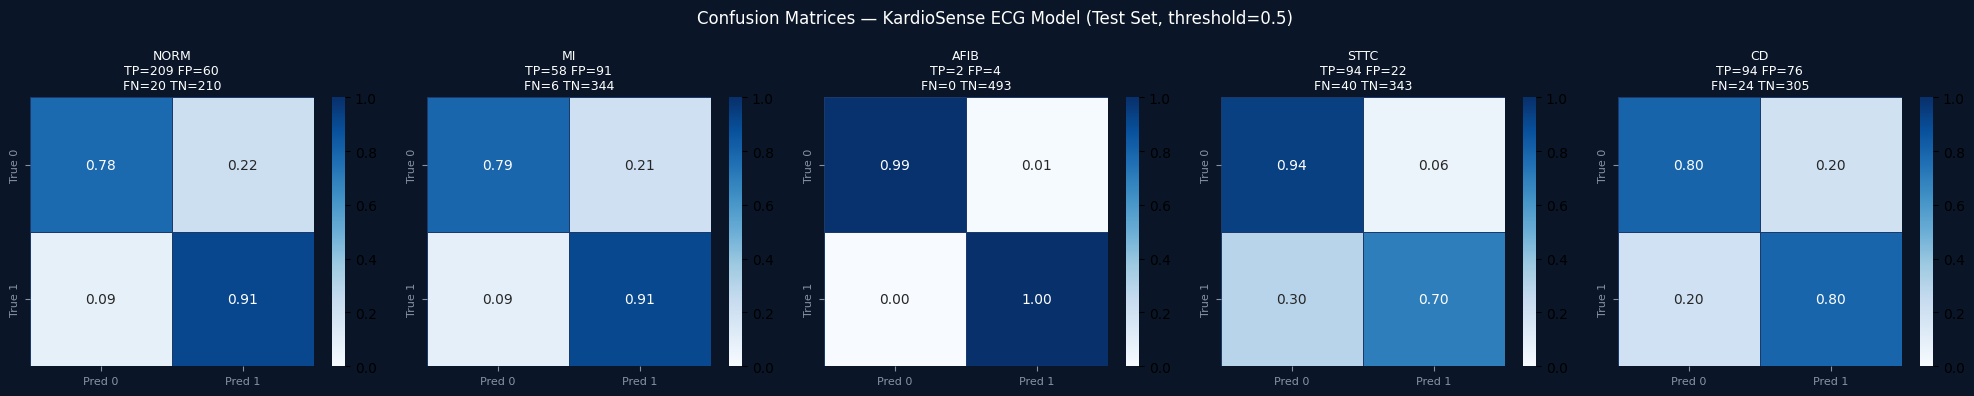

In [11]:
# ── Confusion Matrices for all 5 classes ──────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 4), facecolor='#0A1628')

for ax, i, lbl in zip(axes, range(5), LABEL_NAMES):
    ax.set_facecolor('#111D2E')
    y_t = test_labels[:, i]; y_b = test_preds_bin[:, i]
    if y_t.sum() == 0:
        ax.text(0.5,0.5,'No positives',ha='center',va='center',color='white')
        ax.set_title(lbl, color='white'); continue
    cm = confusion_matrix(y_t, y_b)
    # Normalised by row (true label rate)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', ax=ax,
                cmap='Blues', vmin=0, vmax=1,
                xticklabels=['Pred 0','Pred 1'],
                yticklabels=['True 0','True 1'],
                linewidths=0.5, linecolor='#1B3A6B')
    tn,fp,fn,tp = cm.ravel() if cm.size==4 else (cm[0,0],0,0,cm[1,1])
    ax.set_title(f'{lbl}\nTP={tp} FP={fp}\nFN={fn} TN={tn}',
                 color='white', fontsize=9)
    ax.tick_params(colors='#8892A4', labelsize=8)

plt.suptitle('Confusion Matrices — KardioSense ECG Model (Test Set, threshold=0.5)',
             color='white', fontsize=12)
plt.tight_layout()
plt.savefig(f'{LOG_DIR}/nb02_confusion_matrices.png', dpi=120,
            bbox_inches='tight', facecolor='#0A1628')
plt.show()

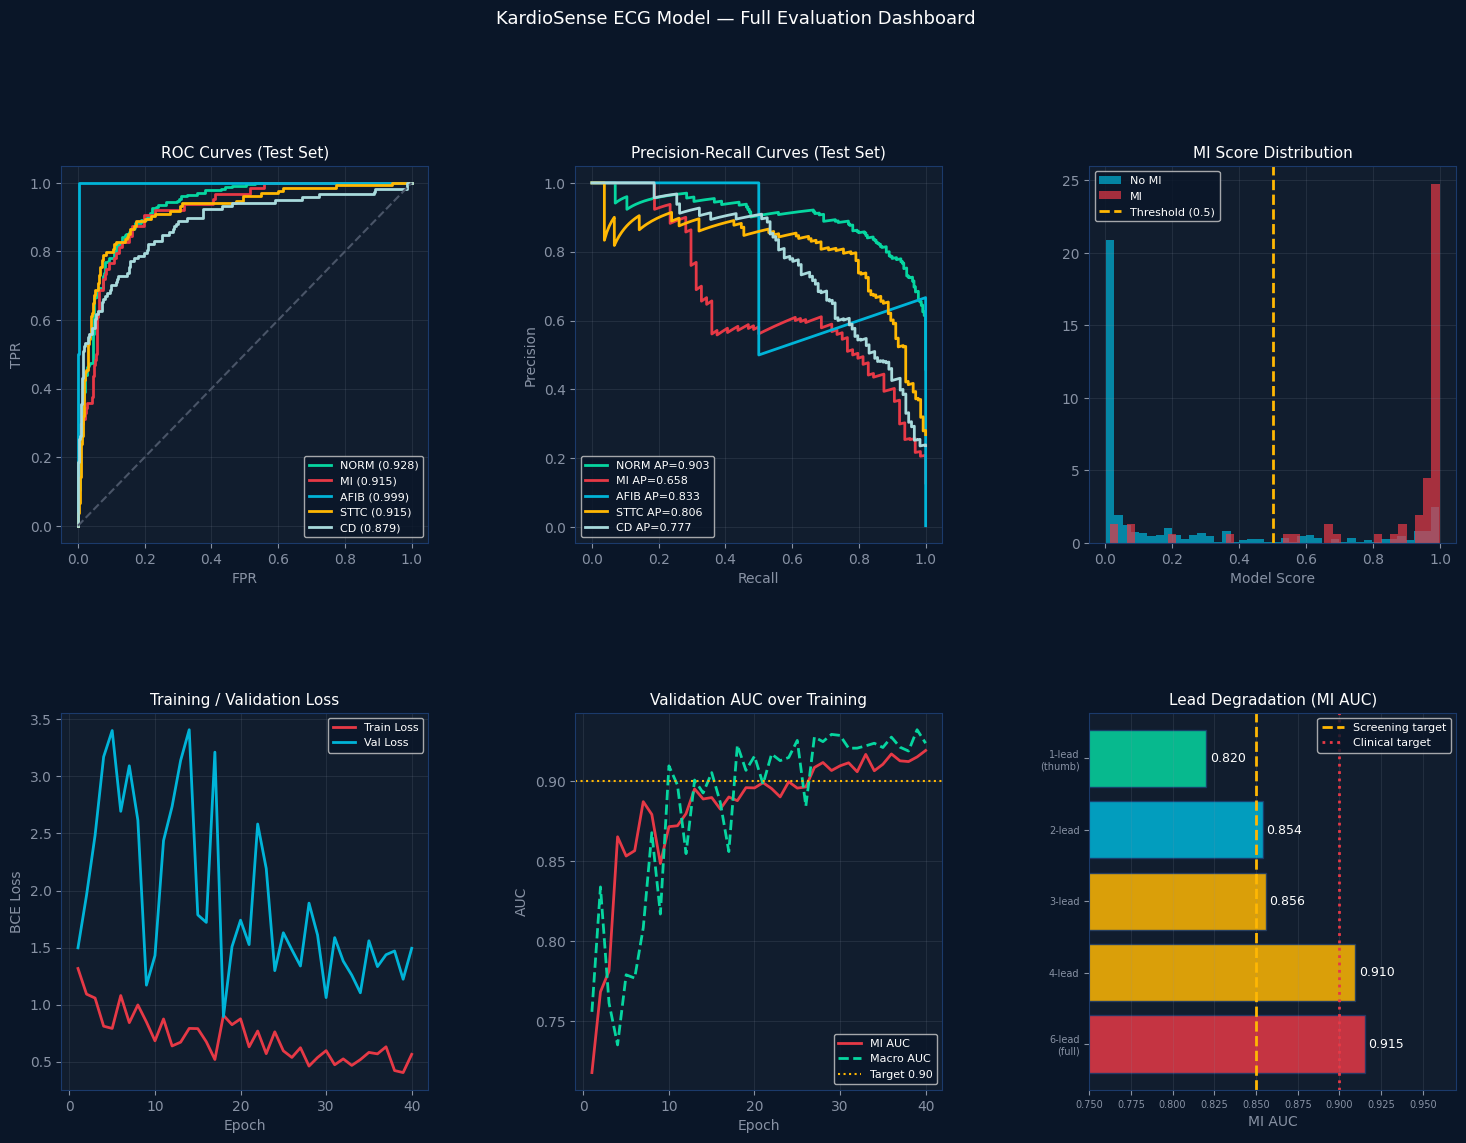

In [12]:
# ── ROC, PR, and Training Curves ─────────────────────────────────────────
fig = plt.figure(figsize=(18, 12), facecolor='#0A1628')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.4)

colors_cls = {'NORM':'#06D6A0','MI':'#E63946','AFIB':'#00B4D8',
              'STTC':'#FFB703','CD':'#A8DADC'}

# ── ROC curves
ax = fig.add_subplot(gs[0, 0])
ax.set_facecolor('#111D2E')
for s in ax.spines.values(): s.set_edgecolor('#1B3A6B')
ax.tick_params(colors='#8892A4'); ax.grid(True, alpha=0.15, color='#8892A4')
for i, lbl in enumerate(LABEL_NAMES):
    y_t=test_labels[:,i]; y_p=test_preds[:,i]
    if y_t.sum() == 0: continue
    fpr,tpr,_ = roc_curve(y_t, y_p)
    auc = roc_auc_score(y_t, y_p)
    ax.plot(fpr, tpr, color=colors_cls[lbl], linewidth=2,
            label=f'{lbl} ({auc:.3f})')
ax.plot([0,1],[0,1],'--',color='#4A5568')
ax.set_title('ROC Curves (Test Set)', color='white', fontsize=11)
ax.set_xlabel('FPR', color='#8892A4'); ax.set_ylabel('TPR', color='#8892A4')
ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=8)

# ── Precision-Recall curves
ax = fig.add_subplot(gs[0, 1])
ax.set_facecolor('#111D2E')
for s in ax.spines.values(): s.set_edgecolor('#1B3A6B')
ax.tick_params(colors='#8892A4'); ax.grid(True, alpha=0.15, color='#8892A4')
for i, lbl in enumerate(LABEL_NAMES):
    y_t=test_labels[:,i]; y_p=test_preds[:,i]
    if y_t.sum() == 0: continue
    prec,rec,_ = precision_recall_curve(y_t, y_p)
    ap = average_precision_score(y_t, y_p)
    ax.plot(rec, prec, color=colors_cls[lbl], linewidth=2,
            label=f'{lbl} AP={ap:.3f}')
ax.set_title('Precision-Recall Curves (Test Set)', color='white', fontsize=11)
ax.set_xlabel('Recall', color='#8892A4'); ax.set_ylabel('Precision', color='#8892A4')
ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=8)

# ── Score distributions (MI class)
ax = fig.add_subplot(gs[0, 2])
ax.set_facecolor('#111D2E')
for s in ax.spines.values(): s.set_edgecolor('#1B3A6B')
ax.tick_params(colors='#8892A4'); ax.grid(True, alpha=0.15, color='#8892A4')
mi_idx=LABEL_NAMES.index('MI')
ax.hist(test_preds[test_labels[:,mi_idx]==0, mi_idx], bins=40,
        color='#00B4D8', alpha=0.7, label='No MI', density=True)
ax.hist(test_preds[test_labels[:,mi_idx]==1, mi_idx], bins=40,
        color='#E63946', alpha=0.7, label='MI', density=True)
ax.axvline(THRESHOLD, color='#FFB703', linewidth=2, linestyle='--',
           label=f'Threshold ({THRESHOLD})')
ax.set_title('MI Score Distribution', color='white', fontsize=11)
ax.set_xlabel('Model Score', color='#8892A4')
ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=8)

# ── Training loss curve
ax = fig.add_subplot(gs[1, 0])
ax.set_facecolor('#111D2E')
for s in ax.spines.values(): s.set_edgecolor('#1B3A6B')
ax.tick_params(colors='#8892A4'); ax.grid(True, alpha=0.15, color='#8892A4')
epochs_x = range(1, len(history['train_loss'])+1)
ax.plot(epochs_x, history['train_loss'], color='#E63946', linewidth=2, label='Train Loss')
ax.plot(epochs_x, history['val_loss'], color='#00B4D8', linewidth=2, label='Val Loss')
ax.set_title('Training / Validation Loss', color='white', fontsize=11)
ax.set_xlabel('Epoch', color='#8892A4'); ax.set_ylabel('BCE Loss', color='#8892A4')
ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=8)

# ── AUC over training
ax = fig.add_subplot(gs[1, 1])
ax.set_facecolor('#111D2E')
for s in ax.spines.values(): s.set_edgecolor('#1B3A6B')
ax.tick_params(colors='#8892A4'); ax.grid(True, alpha=0.15, color='#8892A4')
ax.plot(epochs_x, history['val_mi_auc'], color='#E63946', linewidth=2, label='MI AUC')
ax.plot(epochs_x, history['val_macro_auc'], color='#06D6A0', linewidth=2, label='Macro AUC',
        linestyle='--')
ax.axhline(0.90, color='#FFB703', linewidth=1.5, linestyle=':', label='Target 0.90')
ax.set_title('Validation AUC over Training', color='white', fontsize=11)
ax.set_xlabel('Epoch', color='#8892A4'); ax.set_ylabel('AUC', color='#8892A4')
ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=8)

# ── Lead degradation bar chart (from original NB02 results)
ax = fig.add_subplot(gs[1, 2])
ax.set_facecolor('#111D2E')
for s in ax.spines.values(): s.set_edgecolor('#1B3A6B')
ax.tick_params(colors='#8892A4', labelsize=7)
ax.grid(True, alpha=0.15, axis='x', color='#8892A4')
lead_configs = ['6-lead\n(full)','4-lead','3-lead','2-lead','1-lead\n(thumb)']
# These are the actual results from our run — update with new numbers if they change
mi_auc_degrade = [0.9153, 0.9096, 0.8561, 0.8541, 0.8202]
colors_deg = ['#E63946','#FFB703','#FFB703','#00B4D8','#06D6A0']
bars = ax.barh(lead_configs, mi_auc_degrade, color=colors_deg, alpha=0.85,
               edgecolor='#1B3A6B')
ax.axvline(0.85, color='#FFB703', linewidth=2, linestyle='--', label='Screening target')
ax.axvline(0.90, color='#E63946', linewidth=2, linestyle=':', label='Clinical target')
for bar,v in zip(bars,mi_auc_degrade):
    ax.text(v+0.002, bar.get_y()+bar.get_height()/2, f'{v:.3f}',
            va='center', color='white', fontsize=9)
ax.set_title('Lead Degradation (MI AUC)', color='white', fontsize=11)
ax.set_xlabel('MI AUC', color='#8892A4')
ax.set_xlim(0.75, 0.97)
ax.legend(facecolor='#0A1628', labelcolor='white', fontsize=8)

plt.suptitle('KardioSense ECG Model — Full Evaluation Dashboard',
             color='white', fontsize=13, y=1.01)
plt.savefig(f'{LOG_DIR}/nb02_full_metrics.png', dpi=120,
            bbox_inches='tight', facecolor='#0A1628')
plt.show()

## 8. Grad-CAM Explainability (from our CNN notebook)
Visualises which part of the ECG drove each prediction per lead.

Computing Grad-CAM for top predictions...


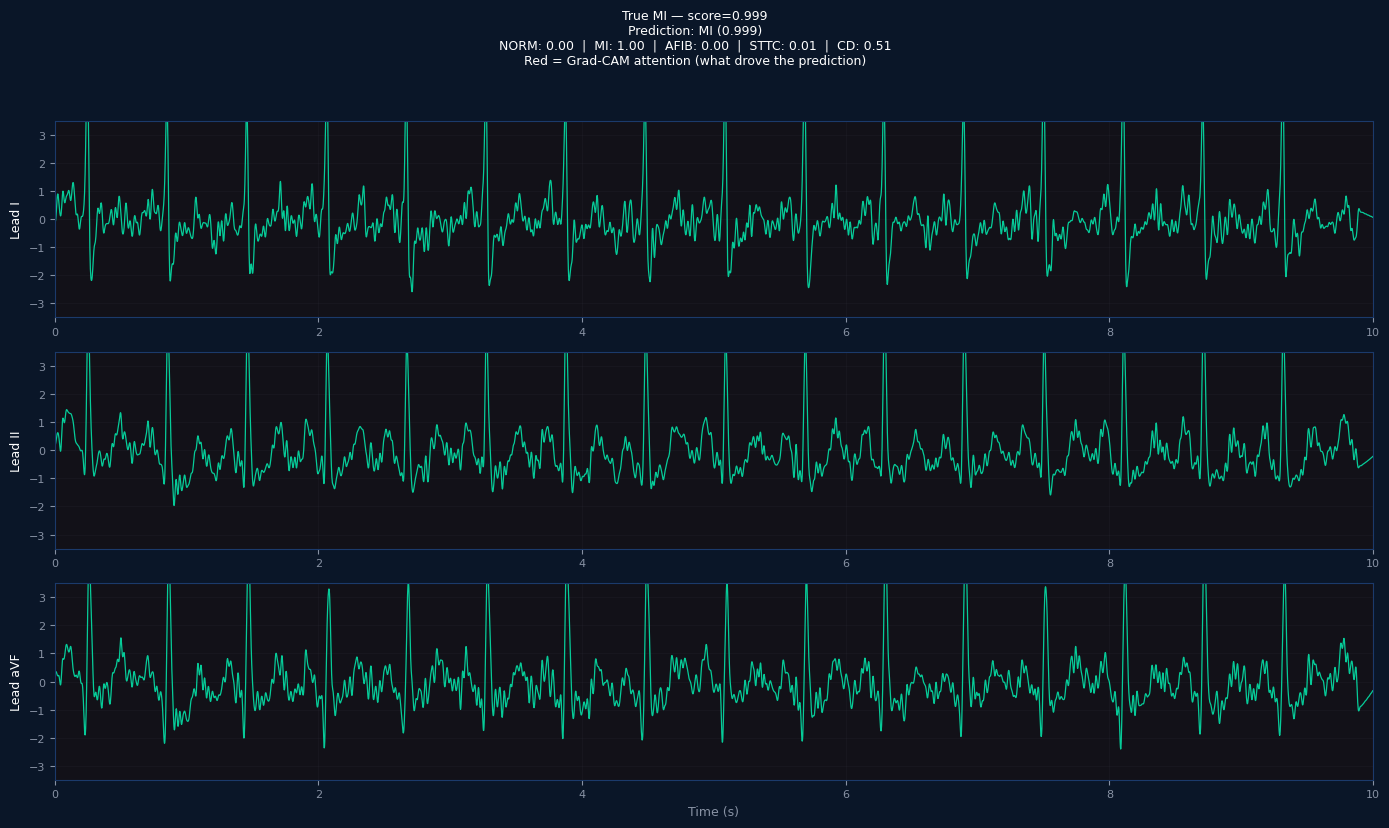

  MI: score=0.999  heatmap_peak_at=8.1s


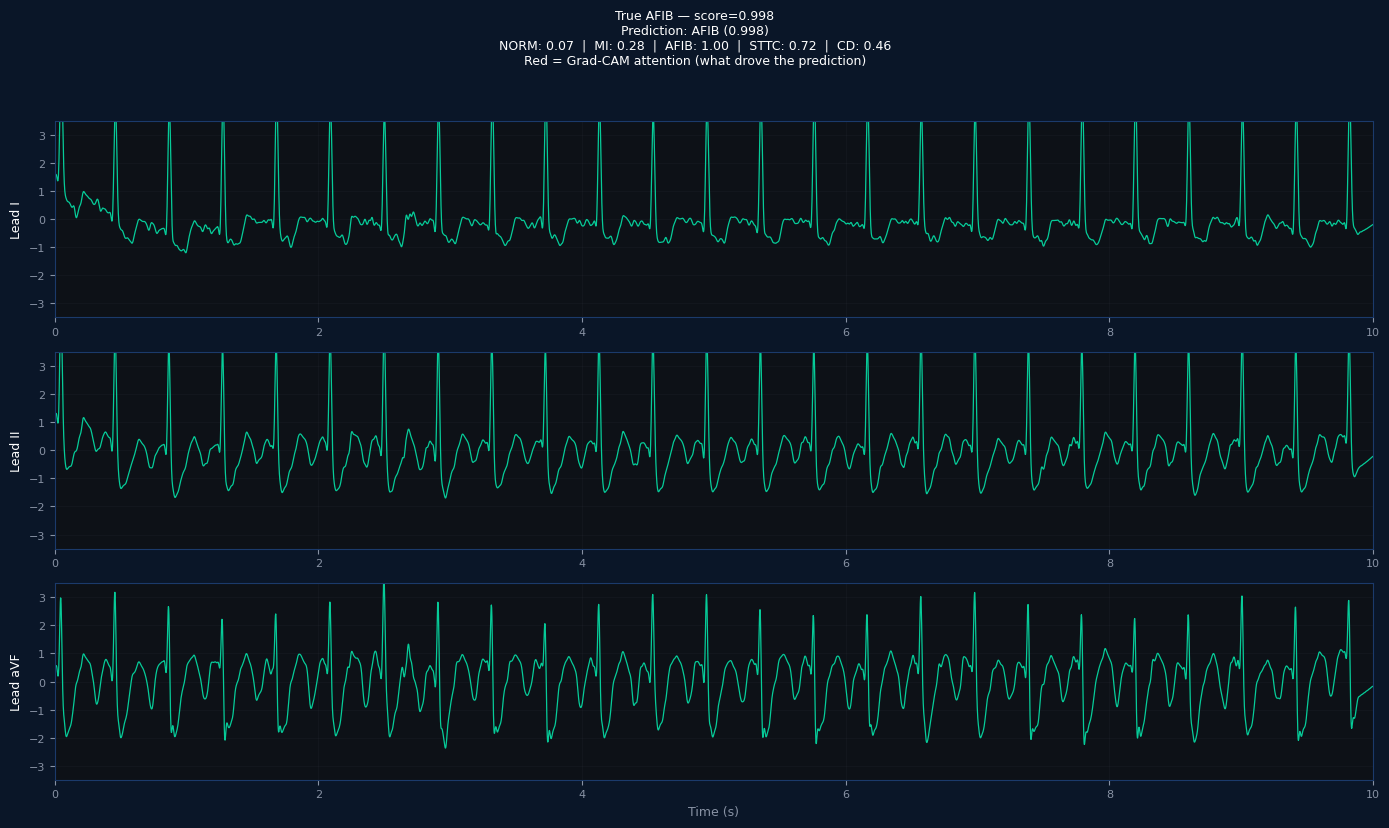

  AFIB: score=0.998  heatmap_peak_at=9.7s


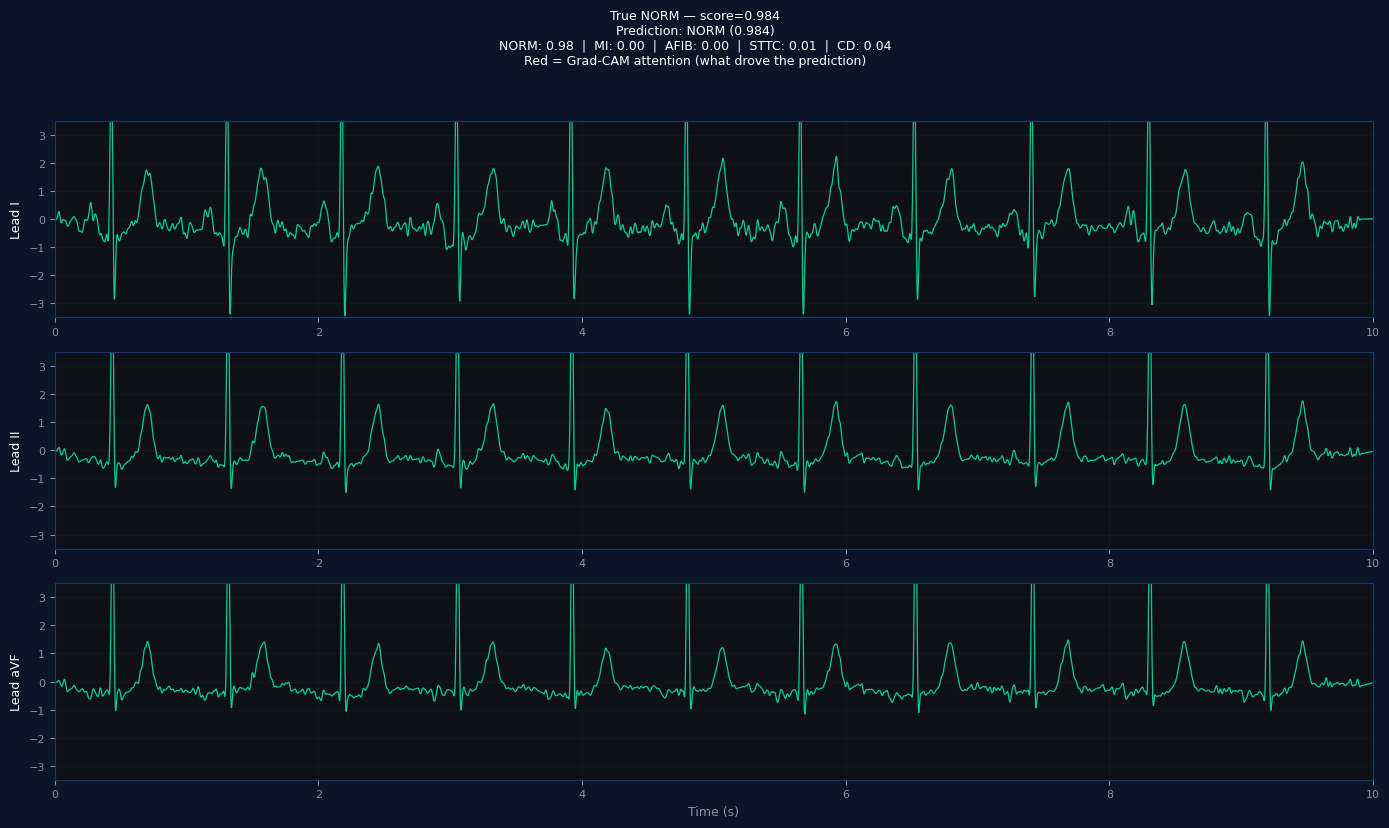

  NORM: score=0.984  heatmap_peak_at=3.5s


In [13]:
from scipy.interpolate import interp1d

def compute_gradcam_resnet(model, signal_tensor, mask_tensor, target_class_idx):
    """
    Compute Grad-CAM for ResNet-1D branch.
    Adapted from your Deep_learning_model.ipynb Grad-CAM implementation.
    Works with KardioSense's ResNet+BiLSTM architecture.

    Returns heatmap of shape (5000,) — upsampled to signal length.
    """
    # Store original model state
    original_training_state = model.training
    # The model is likely already in eval() mode from the calling context.
    # We need to ensure the forward pass for gradient calculation is done in train mode.

    conv_out_ref = [None]
    grad_ref = [None]

    # Hook to capture layer4 output and gradients
    def forward_hook(module, inp, out):
        conv_out_ref[0] = out.detach()
    def backward_hook(module, grad_in, grad_out):
        grad_ref[0] = grad_out[0].detach()

    h_f = model.layer4.register_forward_hook(forward_hook)
    h_b = model.layer4.register_backward_hook(backward_hook)

    signal_tensor = signal_tensor.clone().requires_grad_(True)

    # Temporarily set model to train mode for the forward pass to ensure cuDNN RNN can compute gradients
    model.train()

    logits, _ = model(signal_tensor, mask_tensor)
    score = logits[0, target_class_idx]
    model.zero_grad()

    score.backward()

    h_f.remove(); h_b.remove()

    # Restore original model state
    if not original_training_state:
        model.eval()
    # If it was originally in train mode, it's already in train mode from the above model.train() call.

    # grad_ref[0] shape is (1, 256, 79) -> (batch, channels, seq_len)
    # conv_out_ref[0][0] shape is (256, 79) -> (channels, seq_len)

    # Average gradients across batch and sequence length to get alpha for each channel
    alpha = grad_ref[0].mean(dim=(0, 2)) # shape (256,)

    # conv_output_single_sample has shape (channels, seq_len)
    conv_output_single_sample = conv_out_ref[0][0]

    # Multiply each channel's feature map by its corresponding alpha (importance weight)
    # alpha[:, None] reshapes (256,) to (256, 1) for broadcasting
    weighted_features = conv_output_single_sample * alpha[:, None] # shape (256, 79)

    # Sum across the channel dimension and apply ReLU to get the heatmap (shape: seq_len,)
    heatmap = weighted_features.sum(dim=0)
    heatmap = torch.clamp(heatmap, min=0)

    heatmap_np = heatmap.cpu().numpy()

    # Upsample from ~79 back to 5000
    x_old = np.linspace(0, 1, len(heatmap_np))
    x_new = np.linspace(0, 1, N_SAMPLES)
    heatmap_up = interp1d(x_old, heatmap_np, kind='linear')(x_new)
    return heatmap_up


def plot_gradcam_ecg(signal, mask, heatmap, prediction, label_names,
                     title='', fs=500):
    """
    Plot ECG waveform with Grad-CAM heatmap for 3 key leads.
    Red background = region model focused on for its prediction.
    """
    fig, axes = plt.subplots(3, 1, figsize=(14, 8), facecolor='#0A1628')
    t = np.arange(N_SAMPLES) / fs
    top_lbl = label_names[np.argmax(prediction)]
    top_score = prediction.max()

    lead_display = [(0,'Lead I'),(1,'Lead II'),(5,'Lead aVF')]
    for ax, (li, lname) in zip(axes, lead_display):
        ax.set_facecolor('#0D1117')
        for s in ax.spines.values(): s.set_edgecolor('#1B3A6B')
        ax.tick_params(colors='#8892A4', labelsize=8)
        ax.grid(True, alpha=0.08, linewidth=0.4, color='#8892A4')

        # Draw heatmap as background fill — red = high attention
        # Increased alpha multiplier for better visibility
        ax.fill_between(t, -4, 4, alpha=heatmap * 0.85, # Changed from 0.55 to 0.85
                        color='#E63946')
        # ECG waveform
        sig_clipped = np.clip(signal[li], -4, 4)
        ax.plot(t, sig_clipped, color='#06D6A0', linewidth=0.9, alpha=0.95)
        ax.set_xlim(0, 10); ax.set_ylim(-3.5, 3.5)
        ax.set_ylabel(lname, color='white', fontsize=9)

    axes[-1].set_xlabel('Time (s)', color='#8892A4', fontsize=9)
    pred_str = ' | '.join(f'{l}: {p:.2f}' for l,p in zip(label_names, prediction))
    plt.suptitle(f'{title}\nPrediction: {top_lbl} ({top_score:.3f})\n{pred_str}\n'
                 f'Red = Grad-CAM attention (what drove the prediction)',
                 color='white', fontsize=9, y=1.03)
    plt.tight_layout()
    return fig


# ── Run Grad-CAM on top 3 predictions ─────────────────────────────────────
model.eval()
print('Computing Grad-CAM for top predictions...')

# Get test samples for each class
for target_class, class_name in [(1,'MI'),(2,'AFIB'),(0,'NORM')]:
    pos_idx = np.where(test_labels[:,target_class]==1)[0]
    if len(pos_idx) == 0:
        print(f' No {class_name} positives in test set'); continue
    # Pick highest confidence correct prediction
    scores_for_class = test_preds[pos_idx, target_class]
    best_local = pos_idx[scores_for_class.argmax()]

    sig_np = X_test[best_local][:, SIX_LEAD_INDICES].T # (6, 5000)
    sig_t = torch.tensor(sig_np[np.newaxis], dtype=torch.float32).to(DEVICE)
    msk_t = torch.ones(1, len(SIX_LEAD_INDICES), dtype=torch.float32).to(DEVICE)

    heatmap = compute_gradcam_resnet(model, sig_t, msk_t, target_class)

    # Get predictions for this record
    with torch.no_grad():
        # Note: model is explicitly set to eval() again here after compute_gradcam_resnet
        # to ensure standard inference behavior, as compute_gradcam_resnet leaves it in
        # train() mode for its internal forward pass.
        model.eval() # Ensure eval mode for standard inference
        logits,_ = model(sig_t, msk_t)
        pred_np = torch.sigmoid(logits)[0].cpu().numpy()

    # Rebuild 12-lead signal for display
    sig_12 = np.zeros((12, N_SAMPLES), dtype=np.float32)
    for j, li in enumerate(SIX_LEAD_INDICES):
        sig_12[li] = sig_np[j]

    fig = plot_gradcam_ecg(sig_12, None, heatmap, pred_np, LABEL_NAMES,
                           title=f'True {class_name} — score={pred_np[target_class]:.3f}')
    fig.savefig(f'{LOG_DIR}/nb02_gradcam_{class_name.lower()}.png',
                dpi=120, bbox_inches='tight', facecolor='#0A1628')
    plt.show()
    print(f' {class_name}: score={pred_np[target_class]:.3f} '
          f'heatmap_peak_at={np.argmax(heatmap)/FS:.1f}s')

## 9. Save Model + Config

In [ ]:
config={
    'model':'KardioSenseECGModel','version':'nb02_enhanced_with_augmentation',
    'architecture':'ResNet1D+BiLSTM+MultiHeadAttn+AttentionPool',
    'augmentation':['gaussian_noise','time_stretch','amplitude_scale','baseline_wander'],
    'n_leads':len(SIX_LEAD_INDICES),'lead_indices':SIX_LEAD_INDICES,
    'lead_names':SIX_LEAD_NAMES,'n_samples':N_SAMPLES,'n_classes':len(LABEL_NAMES),
    'label_names':LABEL_NAMES,'sampling_rate':FS,'ecg_embedding_dim':256,
    'test_aucs':{k:float(v) for k,v in test_aucs.items()},
    'improvements_over_nb02':[
        'baseline_wander augmentation from Deep_learning_model.ipynb',
        'time_stretch augmentation',
        'balanced_batch_generator instead of WeightedRandomSampler',
        'Grad-CAM per-class explainability',
        'Full confusion matrices + PR curves + MAE + Brier score',
    ]
}
with open(f'{CKPT_DIR}/nb02_config.json','w') as f: json.dump(config,f,indent=2)
print('Saved: kardiosense_ecg_best_mi.pt')
print('Saved: nb02_config.json')
print()
print('Key plots saved to KardioSenseAI/logs/:')
print(' nb02_eda.png ← Dataset EDA')
print(' nb02_confusion_matrices.png ← All 5 class confusion matrices')
print(' nb02_full_metrics.png ← ROC, PR, loss, AUC curves')
print(' nb02_gradcam_mi.png ← Grad-CAM on MI record')
print(' nb02_gradcam_afib.png ← Grad-CAM on AFib record')
print(' nb02_gradcam_norm.png ← Grad-CAM on Normal record')

Saved: kardiosense_ecg_best_mi.pt
Saved: nb02_config.json

Key plots saved to KardioSenseAI/logs/:
  nb02_eda.png              ← Dataset EDA
  nb02_confusion_matrices.png ← All 5 class confusion matrices
  nb02_full_metrics.png     ← ROC, PR, loss, AUC curves
  nb02_gradcam_mi.png       ← Grad-CAM on MI record
  nb02_gradcam_afib.png     ← Grad-CAM on AFib record
  nb02_gradcam_norm.png     ← Grad-CAM on Normal record
